# Ensemble Learning 02 (2/2) — Voting Ensemble: Regression

### Core idea
Train several regressors on the same data; the ensemble prediction is the **average** of their predictions
(or a **weighted** average).

### In this notebook
1. Averaging regressors on a 1-D example
2. A non-linear dataset: voting beats every member
3. Weights
4. Same algorithm, different depths
5. When voting does not help

> 📖 Theory: [`theory.md`](theory.md) §2 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
CMAP = ListedColormap(['#FA8072', '#1E90FF'])

## 1. What averaging looks like

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

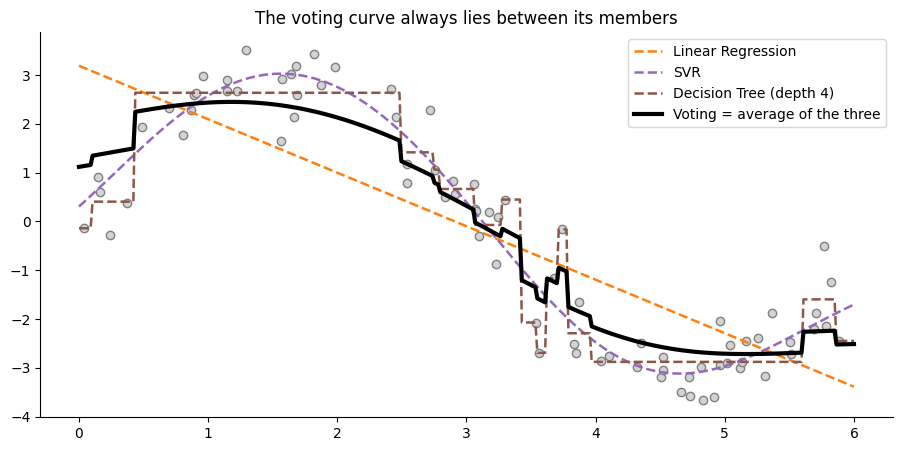

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor

rng = np.random.default_rng(1)
x = np.sort(rng.uniform(0, 6, 80)).reshape(-1, 1)
y1 = np.sin(x).ravel() * 3 + rng.normal(0, 0.6, 80)
grid = np.linspace(0, 6, 400).reshape(-1, 1)

models = [('Linear Regression', LinearRegression()), ('SVR', SVR(C=3)),
          ('Decision Tree (depth 4)', DecisionTreeRegressor(max_depth=4, random_state=0))]
vote = VotingRegressor(models).fit(x, y1)

plt.figure(figsize=(11, 5))
plt.scatter(x, y1, color='lightgray', edgecolor='gray')
for (name, m), color in zip(models, ['tab:orange', 'tab:purple', 'tab:brown']):
    plt.plot(grid, m.fit(x, y1).predict(grid), '--', color=color, linewidth=1.8, label=name)
plt.plot(grid, vote.predict(grid), color='black', linewidth=3, label='Voting = average of the three')
plt.legend()
plt.title('The voting curve always lies between its members')
plt.show()

The black curve is the point-by-point **average** of the three dashed curves. It is pulled toward the straight
line where LR is wrong, so a very bad member can hurt; but it also smooths out the tree's jumps.

## 2. A non-linear dataset

`make_friedman1` generates a target from a non-linear formula of 5 features plus 5 useless noise features. (The
Boston housing dataset used in older tutorials was removed from scikit-learn.)

> ✍️ **Core code: learn this.** `VotingRegressor` works just like `VotingClassifier`.

In [3]:
from sklearn.datasets import make_friedman1
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

X, y = make_friedman1(n_samples=1000, noise=1.0, random_state=42)

estimators = [
    ('lr', LinearRegression()),
    ('knn', KNeighborsRegressor()),
    ('dt', DecisionTreeRegressor(max_depth=6, random_state=0)),
]
for name, model in estimators:
    print(f"{name:>3}: R² = {cross_val_score(model, X, y, cv=10, scoring='r2').mean():.3f}")

vr = VotingRegressor(estimators)
print(f"\nVotingRegressor: R² = {cross_val_score(vr, X, y, cv=10, scoring='r2').mean():.3f}")

 lr: R² = 0.709
knn: R² = 0.654
 dt: R² = 0.617



VotingRegressor: R² = 0.760


The voting regressor (**R² ≈ 0.76**) beats all three of its members (0.71, 0.65, 0.62). Each model captures a
different part of the pattern, and their errors partly cancel.

## 3. Weights

> ✍️ **Core code: learn this.** Try weight combinations 1–3 for each model.

In [4]:
results = []
for i in range(1, 4):
    for j in range(1, 4):
        for k in range(1, 4):
            vr = VotingRegressor(estimators, weights=[i, j, k])
            results.append({'weights (lr, knn, dt)': (i, j, k),
                            'R²': cross_val_score(vr, X, y, cv=10, scoring='r2').mean()})

pd.DataFrame(results).sort_values('R²', ascending=False).head(5).round(3)

,"weights (lr, knn, dt)",R²
22,"(3, 2, 2)",0.762
9,"(2, 1, 1)",0.762
19,"(3, 1, 2)",0.761
23,"(3, 2, 3)",0.760
13,"(2, 2, 2)",0.760


The best weightings are only slightly better than equal weights (0.762 vs 0.760); the models are already balanced.
Weights matter more when the members differ a lot in quality. Choose them with cross-validation, never the test set.

## 4. Same algorithm, different depths

In [5]:
trees = [(f'dt_depth_{d}', DecisionTreeRegressor(max_depth=d, random_state=0)) for d in [3, 5, 7, 9]]

for name, model in trees:
    print(f"{name}: R² = {cross_val_score(model, X, y, cv=10, scoring='r2').mean():.3f}")

print(f"\nVoting of the 4 trees: R² = {cross_val_score(VotingRegressor(trees), X, y, cv=10, scoring='r2').mean():.3f}")

dt_depth_3: R² = 0.514
dt_depth_5: R² = 0.620
dt_depth_7: R² = 0.621


dt_depth_9: R² = 0.618



Voting of the 4 trees: R² = 0.675


Averaging four trees of different depths (**0.675**) beats the best single tree (0.62). Each tree's staircase has
different step positions, and averaging smooths them.

## 5. When voting does not help

In [6]:
strong = [('lr', LinearRegression()), ('dt', DecisionTreeRegressor(random_state=0)), ('svr', SVR())]
for name, model in strong:
    print(f"{name:>3}: R² = {cross_val_score(model, X, y, cv=10, scoring='r2').mean():.3f}")
print(f"\nVotingRegressor: R² = {cross_val_score(VotingRegressor(strong), X, y, cv=10, scoring='r2').mean():.3f}")

 lr: R² = 0.709
 dt: R² = 0.605


svr: R² = 0.813



VotingRegressor: R² = 0.803


Here SVR alone (≈ 0.81) is already much stronger than the others, and the plain average (≈ 0.80) is slightly
**below** it. Voting gives a safe, robust result, but it is not magic. **Experiment and compare.**

---
## Key takeaways
- `VotingRegressor` predicts the **(weighted) average** of its members.
- It works best when members are **diverse and of similar quality**; one very weak member pulls the average down.
- Diversity can come from different algorithms or from different hyperparameters.
- Always compare with the best single model using cross-validation.

➡️ **Next:** [`../03-bagging/01-bagging-classifier.ipynb`](../03-bagging/01-bagging-classifier.ipynb)